# Academic Validation: Mutation & Local Search Mechanics
This notebook rigorously analyzes the behavioral mechanics and statistical efficacy of the Lamarckian mutation operators (Attraction, Repulsion, Pruning) acting upon the Pheromone Matrices.

In [1]:
import os
import random
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from utils_simplified import (
    reuse_citygraph, reuse_ddm, generate_route_system, SimEnvironment, generate_dummy_yaml, run_simulations_parallel,
    build_pheromone_matrix, blend_pheromone_matrix, mutate_attraction, mutate_repulsion, mutate_pruning, crossover_routes
)
from utils.jeep import Jeep
from utils.jeep_system import JeepSystem
from utils.simulation import StaticSurrogateEvaluator
from utils.evaluation_metrics import jaccard_similarity, graph_edit_distance, discrete_frechet_distance

In [2]:
# Initialization & Shared Evaluators
cg = reuse_citygraph("results_and_discussion/pkl/profile_p1.pkl")
ddm = reuse_ddm("results_and_discussion/pkl/ddm_8am.pkl")

os.makedirs("configs", exist_ok=True)
dummy_yaml = "configs/dummy_part3.yaml"
generate_dummy_yaml(dummy_yaml, **{
    "simulation.num_ticks": 200, # fast ticks for sequential simulation
    "simulation.total_allocatable_jeeps": 25,
    "cg_pkl": "results_and_discussion/pkl/profile_p1.pkl",
    "ddm_pkl": "results_and_discussion/pkl/ddm_8am.pkl"
})

with open(dummy_yaml, 'r', encoding='utf-8') as f:
    config_dict = yaml.safe_load(f)

surrogate_eval = StaticSurrogateEvaluator(config_dict, cg, ddm, num_samples=100)

# Read seconds_per_tick from config_dict
sec_per_tick = config_dict.get("simulation", {}).get("seconds_per_tick", 1)

def make_jeep_sys(routes, num_jeeps=25):
    jeeps = []
    jeeps_per_route = max(1, num_jeeps // len(routes))
    for r in routes:
        for _ in range(jeeps_per_route):
            start_coord = (r.path[0].start.lon, r.path[0].start.lat)
            jeeps.append(Jeep(r, curr_pos=start_coord, speed=40.0, max_capacity=16, seconds_per_tick=sec_per_tick))
    return JeepSystem(jeeps=jeeps, routes=routes, weight_tolerance=50.0, equidistant_spawn=True)


[INFO] Reusing CityGraph from pickle file: results_and_discussion/pkl/profile_p1.pkl
[INFO] Reusing DirectDemandSampler from pickle file: results_and_discussion/pkl/ddm_8am.pkl
[INFO] Generating dummy YAML at configs/dummy_part3.yaml with overrides: {'simulation.num_ticks': 200, 'simulation.total_allocatable_jeeps': 25, 'cg_pkl': 'results_and_discussion/pkl/profile_p1.pkl', 'ddm_pkl': 'results_and_discussion/pkl/ddm_8am.pkl'}


Generating Baseline Setups:   0%|          | 0/10 [00:00<?, ?it/s]

[INFO] Generating 4 routes...
[INFO] Building TravelGraph using config from: configs/dummy_part3.yaml
[INFO] Generating 4 routes...
[INFO] Building TravelGraph using config from: configs/dummy_part3.yaml
[INFO] Generating 4 routes...
[INFO] Building TravelGraph using config from: configs/dummy_part3.yaml
[INFO] Generating 4 routes...
[INFO] Building TravelGraph using config from: configs/dummy_part3.yaml
[INFO] Generating 4 routes...
[INFO] Building TravelGraph using config from: configs/dummy_part3.yaml
[INFO] Generating 4 routes...
[INFO] Building TravelGraph using config from: configs/dummy_part3.yaml
[INFO] Generating 4 routes...
[INFO] Building TravelGraph using config from: configs/dummy_part3.yaml
[INFO] Generating 4 routes...
[INFO] Building TravelGraph using config from: configs/dummy_part3.yaml
[INFO] Generating 4 routes...
[INFO] Building TravelGraph using config from: configs/dummy_part3.yaml
[INFO] Generating 4 routes...
[INFO] Building TravelGraph using config from: confi

Running Simulations:   0%|          | 0/10 [00:00<?, ?it/s]

[INFO] Initializing simulation from YAML: configs/dummy_part3.yaml
[INFO] Running simulation for 200 ticks...


[INFO] Initializing simulation from YAML: configs/dummy_part3.yaml
[INFO] Running simulation for 200 ticks...


...

[INFO] Initializing simulation from YAML: configs/dummy_part3.yaml
[INFO] Running simulation for 200 ticks...


[INFO] Initializing simulation from YAML: configs/dummy_part3.yaml
[INFO] Running simulation for 200 ticks...


[INFO] Initializing simulation from YAML: configs/dummy_part3.yaml
[INFO] Running simulation for 200 ticks...


[INFO] Initializing simulation from YAML: configs/dummy_part3.yaml
[INFO] Running simulation for 200 ticks...


[INFO] Initializing simulation from YAML: configs/dummy_part3.yaml
[INFO] Running simulation for 200 ticks...


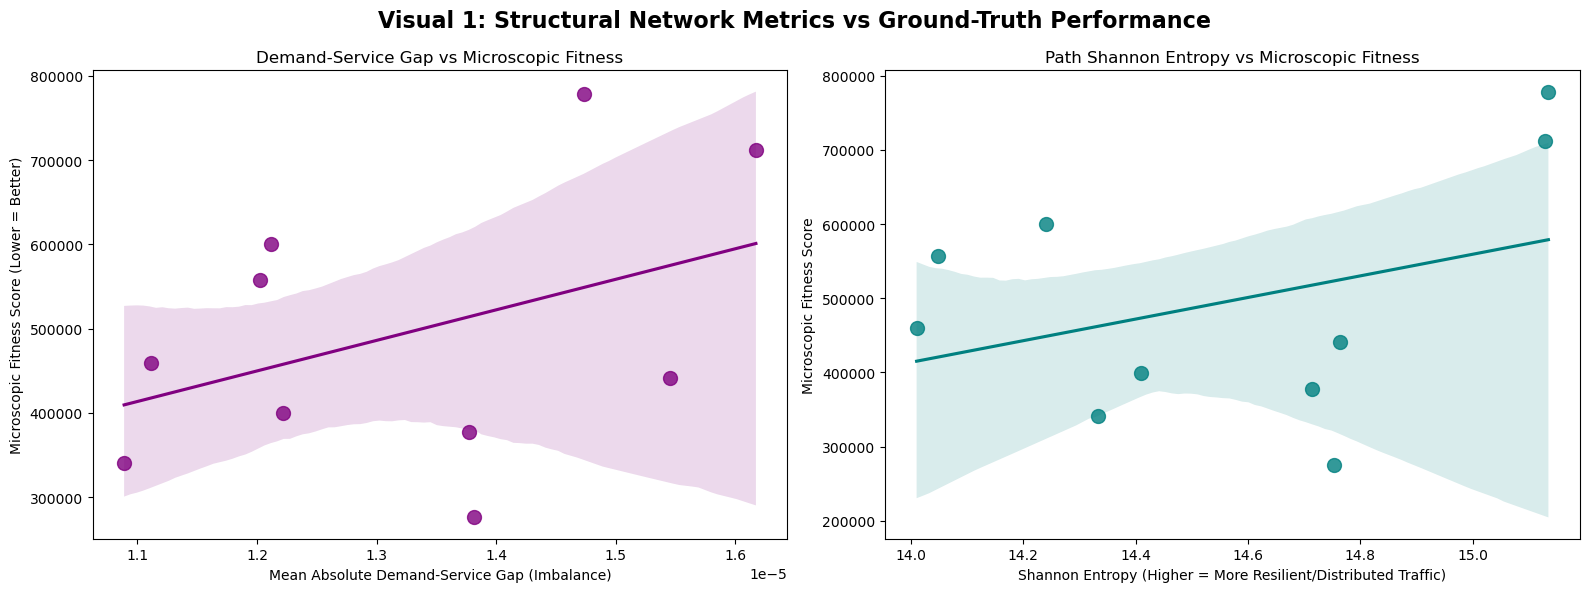

In [3]:
# Part A: Demand-Service Gaps & Entropy vs Fitness
from utils.evaluation_metrics import shannon_entropy

from utils_simplified import build_travelgraph
N_SAMPLES = 10
envs = []
for _ in tqdm(range(N_SAMPLES), desc="Generating Baseline Setups"):
    r_sys = generate_route_system(4, cg, ddm)
    j_sys = make_jeep_sys(r_sys)
    tg_obj = build_travelgraph(cg, dummy_yaml, r_sys)
    envs.append(SimEnvironment(tg=tg_obj, yaml_file=dummy_yaml, jeep_system=j_sys, sampler=ddm, delete_yaml_when_done=False))

print("Running microscopic simulations for Part A...")
from utils_simplified import run_simulation_env
micro_results = []
for env in tqdm(envs, desc="Running Simulations", leave=False):
    sim = run_simulation_env(env)
    micro_results.append(sim.evaluate_fitness())

abs_gaps = []
entropies = []
fitnesses = []
for i, res in enumerate(micro_results):
    matrix = build_pheromone_matrix(cg, res)
    # The jeep_system was stripped for IPC, so we re-compute gaps using the local jeep system
    matrix.gaps = matrix.calculate_demand_service_gaps(envs[i].jeep_system)
    
    gaps_list = list(matrix.gaps.values())
    mean_abs_gap = np.mean(np.abs(gaps_list)) if gaps_list else 0.0
    abs_gaps.append(mean_abs_gap)
    
    # Calculate Shannon Entropy of the pheromone distribution (Edge Traversals)
    entropy = shannon_entropy(matrix.tau)
    entropies.append(entropy)
    
    fitnesses.append(res.fitness_score)

df_gaps = pd.DataFrame({"Mean Absolute Gap": abs_gaps, "Shannon Entropy": entropies, "Fitness Score": fitnesses})

fig, axes = plt.subplots(1, 2, figsize=(16,6))

sns.regplot(data=df_gaps, x="Mean Absolute Gap", y="Fitness Score", ax=axes[0], scatter_kws={'s':100, 'alpha':0.8}, color="purple")
axes[0].set_title("Demand-Service Gap vs Microscopic Fitness")
axes[0].set_xlabel("Mean Absolute Demand-Service Gap (Imbalance)")
axes[0].set_ylabel("Microscopic Fitness Score (Lower = Better)")

sns.regplot(data=df_gaps, x="Shannon Entropy", y="Fitness Score", ax=axes[1], scatter_kws={'s':100, 'alpha':0.8}, color="teal")
axes[1].set_title("Path Shannon Entropy vs Microscopic Fitness")
axes[1].set_xlabel("Shannon Entropy (Higher = More Resilient/Distributed Traffic)")
axes[1].set_ylabel("Microscopic Fitness Score")

plt.suptitle("Visual 1: Structural Network Metrics vs Ground-Truth Performance", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/rx/kblrj3c10fv8wymvkvn_nh7r0000gn/T/ipykernel_38630/3804882348.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('Set1')(np.linspace(0, 1, len(routes)))


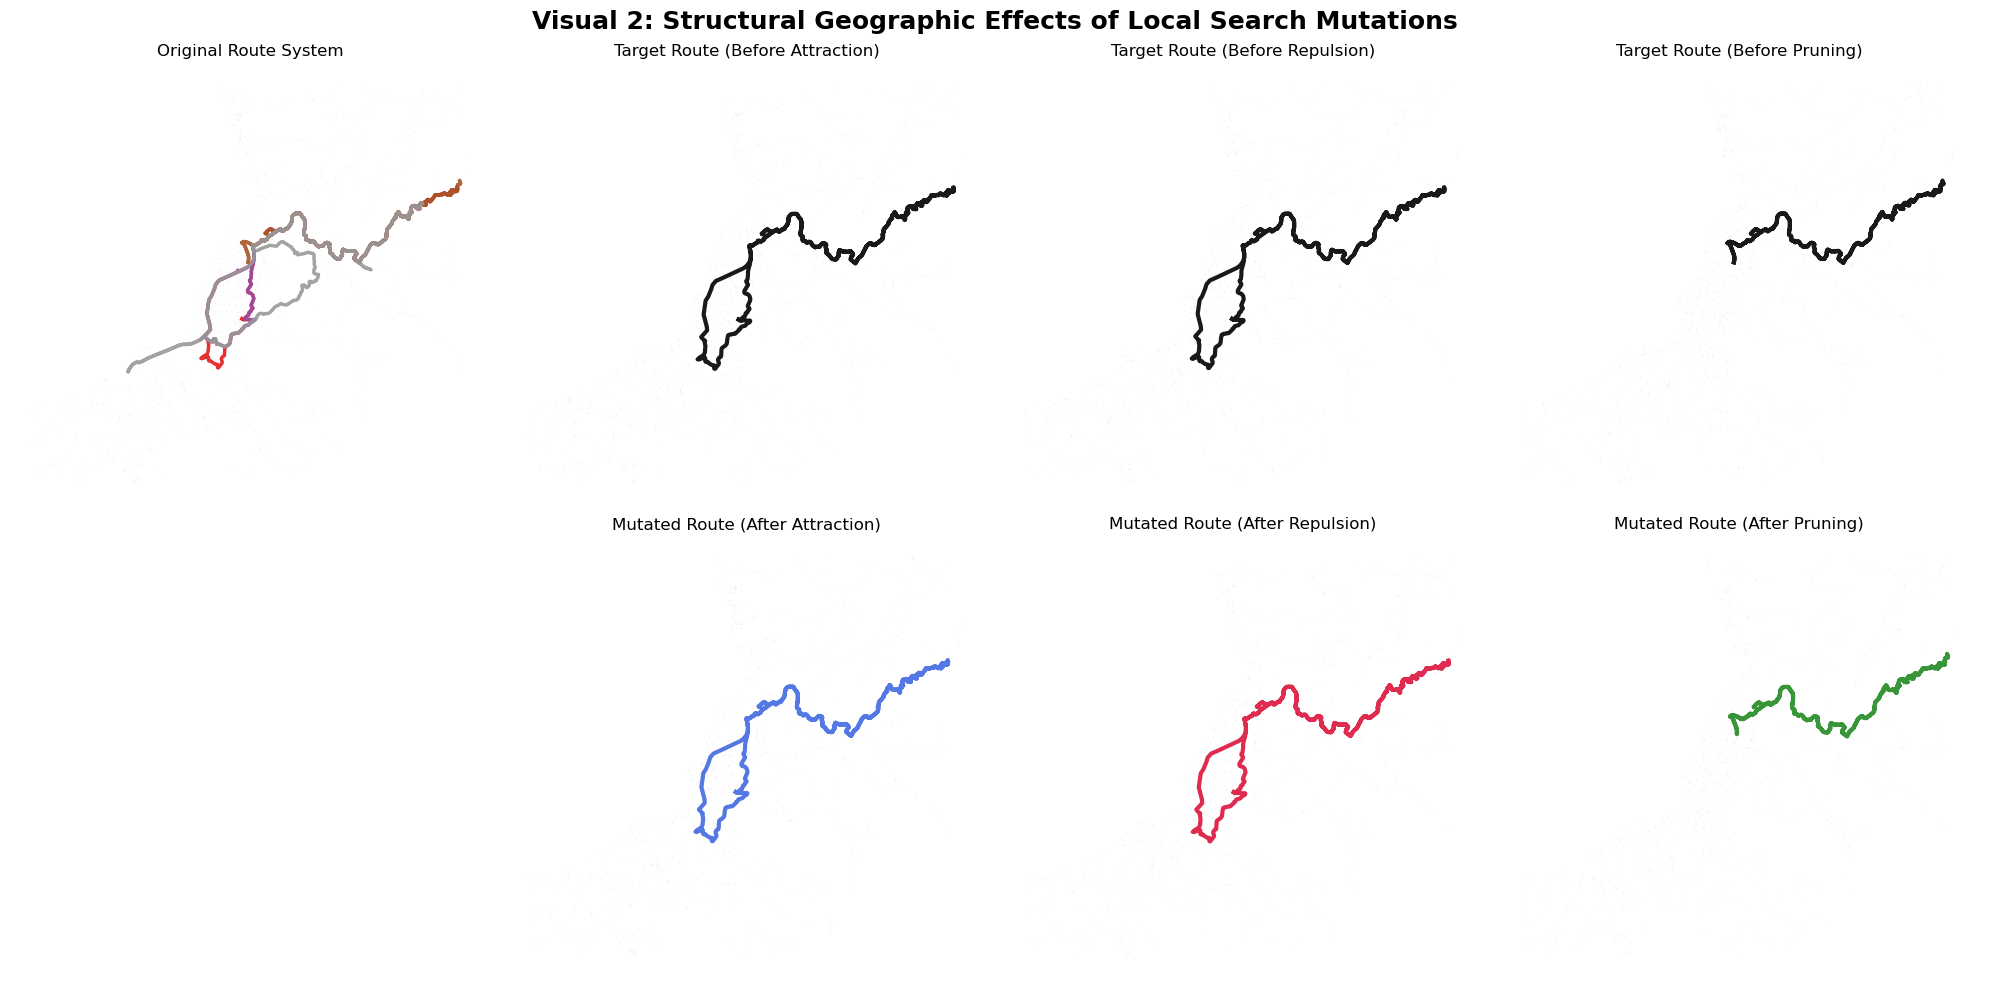

In [4]:
# Part B: Geographic Map Snapshots
import matplotlib.cm as cm

def plot_single_route_mpl(ax, route, title, color):
    for e in random.sample(list(cg.graph), min(2000, len(cg.graph))):
        ax.plot([e.start.lon, e.end.lon], [e.start.lat, e.end.lat], color='gray', alpha=0.1, linewidth=0.5)
        
    if route:
        lons = [e.start.lon for e in route.path] + [route.path[-1].end.lon]
        lats = [e.start.lat for e in route.path] + [route.path[-1].end.lat]
        ax.plot(lons, lats, color=color, linewidth=3.0, alpha=0.9)
    ax.set_title(title)
    ax.axis('off')

def plot_system_mpl(ax, routes, title):
    colors = cm.get_cmap('Set1')(np.linspace(0, 1, len(routes)))
    for e in random.sample(list(cg.graph), min(2000, len(cg.graph))):
        ax.plot([e.start.lon, e.end.lon], [e.start.lat, e.end.lat], color='gray', alpha=0.1, linewidth=0.5)
        
    for i, r in enumerate(routes):
        lons = [e.start.lon for e in r.path] + [r.path[-1].end.lon]
        lats = [e.start.lat for e in r.path] + [r.path[-1].end.lat]
        ax.plot(lons, lats, color=colors[i], linewidth=2.5, alpha=0.9)
    ax.set_title(title)
    ax.axis('off')

base_routes = envs[0].jeep_system.routes
base_matrix = build_pheromone_matrix(cg, micro_results[0])

attracted_routes = mutate_attraction(base_matrix, base_routes, cg)
repulsed_routes = mutate_repulsion(base_matrix, base_routes, cg)
pruned_routes = mutate_pruning(base_matrix, base_routes, cg)

# Identify which route was mutated
def find_mutated_pair(orig_system, mut_system):
    for orig_r, mut_r in zip(orig_system, mut_system):
        if [getattr(e, 'id', id(e)) for e in orig_r.path] != [getattr(e, 'id', id(e)) for e in mut_r.path]:
            return orig_r, mut_r
    return orig_system[0], mut_system[0]

orig_a, mut_a = find_mutated_pair(base_routes, attracted_routes)
orig_r, mut_r = find_mutated_pair(base_routes, repulsed_routes)
orig_p, mut_p = find_mutated_pair(base_routes, pruned_routes)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Column 1: Full System
plot_system_mpl(axes[0, 0], base_routes, "Original Route System")
axes[1, 0].axis('off') # Hide bottom left

# Column 2: Attraction
plot_single_route_mpl(axes[0, 1], orig_a, "Target Route (Before Attraction)", "black")
plot_single_route_mpl(axes[1, 1], mut_a, "Mutated Route (After Attraction)", "royalblue")

# Column 3: Repulsion
plot_single_route_mpl(axes[0, 2], orig_r, "Target Route (Before Repulsion)", "black")
plot_single_route_mpl(axes[1, 2], mut_r, "Mutated Route (After Repulsion)", "crimson")

# Column 4: Pruning
plot_single_route_mpl(axes[0, 3], orig_p, "Target Route (Before Pruning)", "black")
plot_single_route_mpl(axes[1, 3], mut_p, "Mutated Route (After Pruning)", "forestgreen")

plt.suptitle("Visual 2: Structural Geographic Effects of Local Search Mutations", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

Generating 20 random systems for statistical mutation impact...


Generating Statistic Setups:   0%|          | 0/20 [00:00<?, ?it/s]

[INFO] Generating 4 routes...
[INFO] Building TravelGraph using config from: configs/dummy_part3.yaml
[INFO] Generating 4 routes...
[INFO] Building TravelGraph using config from: configs/dummy_part3.yaml
[INFO] Generating 4 routes...
[INFO] Building TravelGraph using config from: configs/dummy_part3.yaml
[INFO] Generating 4 routes...
[INFO] Building TravelGraph using config from: configs/dummy_part3.yaml
[INFO] Generating 4 routes...
[INFO] Building TravelGraph using config from: configs/dummy_part3.yaml
[INFO] Generating 4 routes...
[INFO] Building TravelGraph using config from: configs/dummy_part3.yaml
[INFO] Generating 4 routes...
[INFO] Building TravelGraph using config from: configs/dummy_part3.yaml
[INFO] Generating 4 routes...
[INFO] Building TravelGraph using config from: configs/dummy_part3.yaml
[INFO] Generating 4 routes...
[INFO] Building TravelGraph using config from: configs/dummy_part3.yaml
[INFO] Generating 4 routes...
[INFO] Building TravelGraph using config from: confi

Running Simulations:   0%|          | 0/20 [00:00<?, ?it/s]

[INFO] Initializing simulation from YAML: configs/dummy_part3.yaml
[INFO] Running simulation for 200 ticks...


...

[INFO] Initializing simulation from YAML: configs/dummy_part3.yaml
[INFO] Running simulation for 200 ticks...


[INFO] Initializing simulation from YAML: configs/dummy_part3.yaml
[INFO] Running simulation for 200 ticks...


[INFO] Initializing simulation from YAML: configs/dummy_part3.yaml
[INFO] Running simulation for 200 ticks...


Evaluating Mutations via Surrogate:   0%|          | 0/20 [00:00<?, ?it/s]

/var/folders/rx/kblrj3c10fv8wymvkvn_nh7r0000gn/T/ipykernel_38630/2721494383.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mut, x="Operator", y="Cost Delta", palette="pastel")


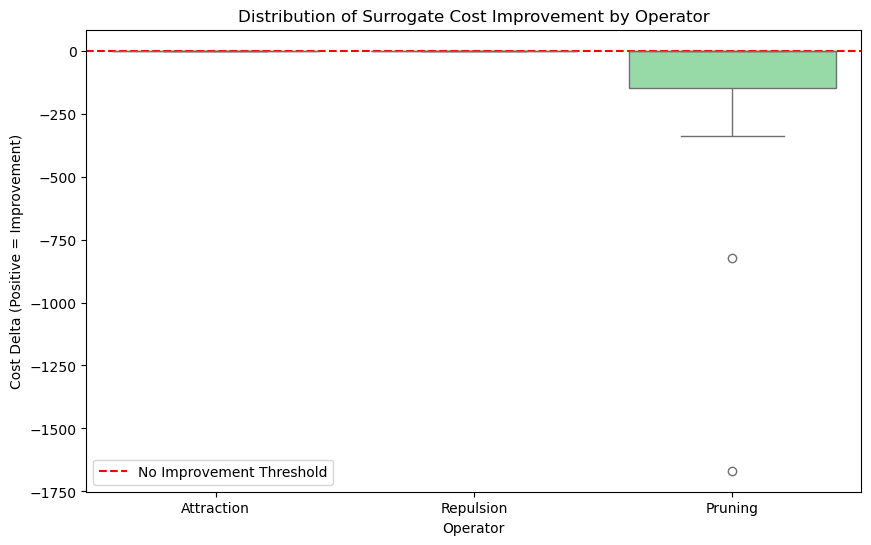

=== Operator Reliability ===
Percentage of times operator improved the surrogate route cost:
Operator
Attraction    0.0
Pruning       0.0
Repulsion     0.0
Name: Improved, dtype: float64


In [5]:
# Part C: Statistical Impact of Mutations
print("Generating 20 random systems for statistical mutation impact...")
from utils_simplified import build_travelgraph
N_STATS = 20
envs_stat = []
for _ in tqdm(range(N_STATS), desc="Generating Statistic Setups"):
    r_sys = generate_route_system(4, cg, ddm)
    j_sys = make_jeep_sys(r_sys)
    tg_obj = build_travelgraph(cg, dummy_yaml, r_sys)
    envs_stat.append(SimEnvironment(tg=tg_obj, yaml_file=dummy_yaml, jeep_system=j_sys, sampler=ddm, delete_yaml_when_done=False))

from utils_simplified import run_simulation_env
micro_stat_results = []
for env in tqdm(envs_stat, desc="Running Simulations", leave=False):
    sim = run_simulation_env(env)
    micro_stat_results.append(sim.evaluate_fitness())

mutation_data = []

for i in tqdm(range(N_STATS), desc="Evaluating Mutations via Surrogate"):
    base_r = envs_stat[i].jeep_system.routes
    base_m = build_pheromone_matrix(cg, micro_stat_results[i])
    
    base_cost = surrogate_eval.evaluate(base_r).surrogate_cost
    
    mut_a = mutate_attraction(base_m, base_r, cg)
    mut_r = mutate_repulsion(base_m, base_r, cg)
    mut_p = mutate_pruning(base_m, base_r, cg)
    
    cost_a = surrogate_eval.evaluate(mut_a).surrogate_cost
    cost_r = surrogate_eval.evaluate(mut_r).surrogate_cost
    cost_p = surrogate_eval.evaluate(mut_p).surrogate_cost
    
    mutation_data.append({"Operator": "Attraction", "Cost Delta": base_cost - cost_a, "Improved": cost_a < base_cost})
    mutation_data.append({"Operator": "Repulsion", "Cost Delta": base_cost - cost_r, "Improved": cost_r < base_cost})
    mutation_data.append({"Operator": "Pruning", "Cost Delta": base_cost - cost_p, "Improved": cost_p < base_cost})

df_mut = pd.DataFrame(mutation_data)
df_mut = df_mut[(df_mut['Cost Delta'] < 50000) & (df_mut['Cost Delta'] > -50000)]

plt.figure(figsize=(10,6))
sns.boxplot(data=df_mut, x="Operator", y="Cost Delta", palette="pastel")
plt.axhline(0, color='red', linestyle='--', label="No Improvement Threshold")
plt.title("Distribution of Surrogate Cost Improvement by Operator")
plt.ylabel("Cost Delta (Positive = Improvement)")
plt.legend()
plt.show()

improved_pct = df_mut.groupby("Operator")["Improved"].mean() * 100
print("=== Operator Reliability ===")
print("Percentage of times operator improved the surrogate route cost:")
print(improved_pct)

Comparing Self-Matrix vs Blended-Matrix crossover...


Evaluating Crossover Logic:   0%|          | 0/10 [00:00<?, ?it/s]

/var/folders/rx/kblrj3c10fv8wymvkvn_nh7r0000gn/T/ipykernel_38630/902125956.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cross, x="Strategy", y="Improvement", capsize=0.1, palette="mako")


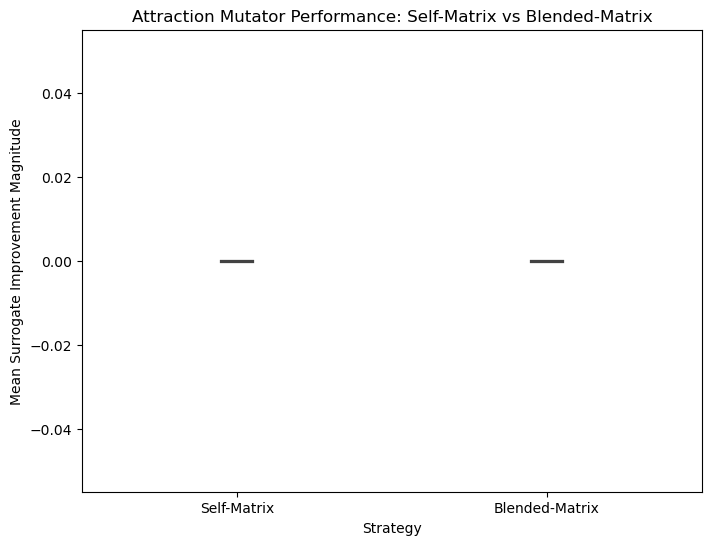

In [6]:
# Part D: Self-Matrix vs Blended-Matrix Comparison
print("Comparing Self-Matrix vs Blended-Matrix crossover...")
crossover_data = []

for i in tqdm(range(0, N_STATS - 1, 2), desc="Evaluating Crossover Logic"):
    p1_r = envs_stat[i].jeep_system.routes
    p1_m = build_pheromone_matrix(cg, micro_stat_results[i])
    p1_cost = micro_stat_results[i].fitness_score
    
    p2_r = envs_stat[i+1].jeep_system.routes
    p2_m = build_pheromone_matrix(cg, micro_stat_results[i+1])
    p2_cost = micro_stat_results[i+1].fitness_score
    
    child_r = crossover_routes(p1_r, p1_m, p2_r, cg)
    
    class DummyChrom:
        def __init__(self, c, p): self.cost, self.pheromones = c, p
    p1_chrom = DummyChrom(p1_cost, p1_m)
    p2_chrom = DummyChrom(p2_cost, p2_m)
    blended_m = blend_pheromone_matrix(p1_chrom, p2_chrom, cg)
    
    child_base_cost = surrogate_eval.evaluate(child_r).surrogate_cost
    
    child_self_mut = mutate_attraction(p1_m, child_r, cg)
    child_self_cost = surrogate_eval.evaluate(child_self_mut).surrogate_cost
    
    child_blend_mut = mutate_attraction(blended_m, child_r, cg)
    child_blend_cost = surrogate_eval.evaluate(child_blend_mut).surrogate_cost
    
    crossover_data.append({"Strategy": "Self-Matrix", "Improvement": child_base_cost - child_self_cost})
    crossover_data.append({"Strategy": "Blended-Matrix", "Improvement": child_base_cost - child_blend_cost})

df_cross = pd.DataFrame(crossover_data)
df_cross = df_cross[(df_cross['Improvement'] < 50000) & (df_cross['Improvement'] > -50000)]

plt.figure(figsize=(8,6))
sns.barplot(data=df_cross, x="Strategy", y="Improvement", capsize=0.1, palette="mako")
plt.title("Attraction Mutator Performance: Self-Matrix vs Blended-Matrix")
plt.ylabel("Mean Surrogate Improvement Magnitude")
plt.show()

Evaluating Structural Distances...


Computing Topological Distances:   0%|          | 0/20 [00:00<?, ?it/s]

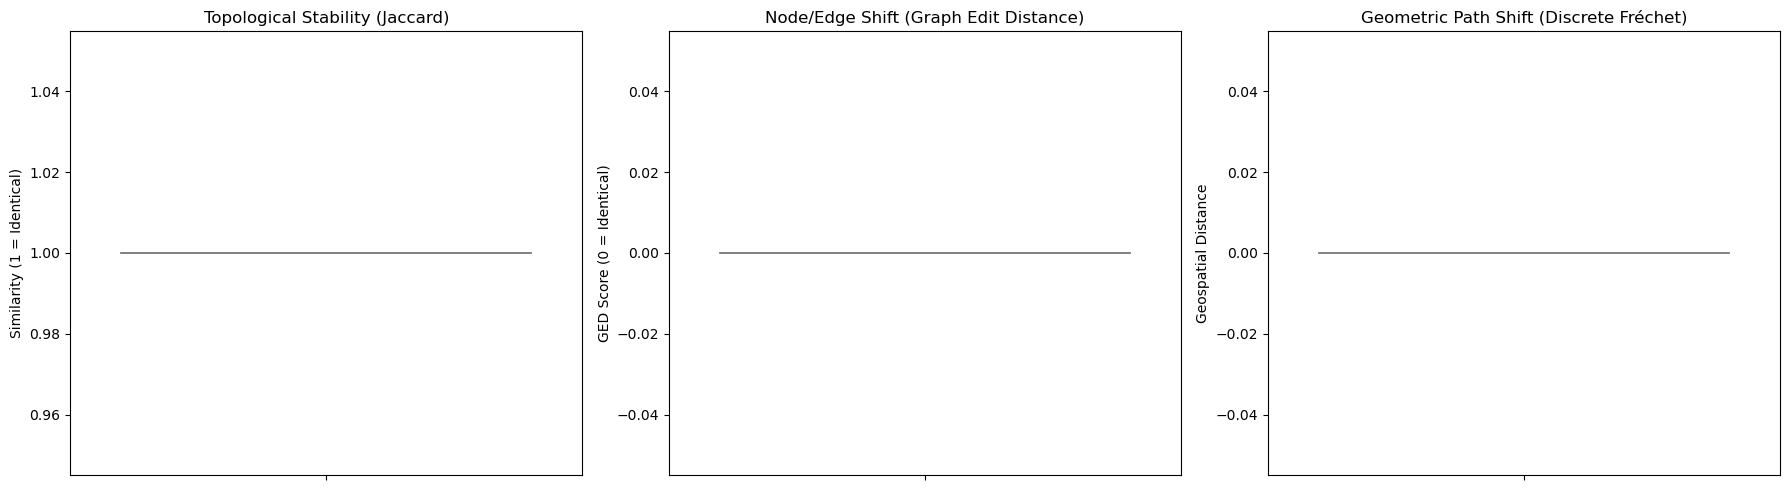

In [7]:
# Part E: Structural Similarity Metrics
print("Evaluating Structural Distances...")
jaccards, geds, frechets = [], [], []

for i in tqdm(range(N_STATS), desc="Computing Topological Distances"):
    base_r = envs_stat[i].jeep_system.routes
    base_m = build_pheromone_matrix(cg, micro_stat_results[i])
    mut_a = mutate_attraction(base_m, base_r, cg)
    
    edges_base = [e for r in base_r for e in r.path]
    edges_mut = [e for r in mut_a for e in r.path]
    
    jaccards.append(jaccard_similarity(edges_base, edges_mut))
    geds.append(graph_edit_distance(edges_base, edges_mut, max_nodes=6)) # fast GED
    
    if base_r and mut_a:
        coords_base = [(e.start.lat, e.start.lon) for e in base_r[0].path]
        coords_mut = [(e.start.lat, e.start.lon) for e in mut_a[0].path]
        frechets.append(discrete_frechet_distance(coords_base, coords_mut))

df_sim = pd.DataFrame({
    "Jaccard Similarity": jaccards,
    "Graph Edit Distance": geds,
    "Frechet Distance (R0)": frechets
})

fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.violinplot(data=df_sim, y="Jaccard Similarity", ax=axes[0], color="skyblue")
axes[0].set_title("Topological Stability (Jaccard)")
axes[0].set_ylabel("Similarity (1 = Identical)")

sns.violinplot(data=df_sim, y="Graph Edit Distance", ax=axes[1], color="lightcoral")
axes[1].set_title("Node/Edge Shift (Graph Edit Distance)")
axes[1].set_ylabel("GED Score (0 = Identical)")

sns.violinplot(data=df_sim, y="Frechet Distance (R0)", ax=axes[2], color="lightgreen")
axes[2].set_title("Geometric Path Shift (Discrete Fréchet)")
axes[2].set_ylabel("Geospatial Distance")

plt.tight_layout()
plt.show()

# Final Cleanup
try:
    if os.path.exists(dummy_yaml):
        os.remove(dummy_yaml)
except Exception:
    pass